In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
print("sklearn", sklearn.__version__)

sklearn 1.6.1


In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(df.shape)
print(df["Churn"].value_counts())

(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [3]:
y = df["Churn"]
X = df.drop(columns=["Churn", "customerID"])

print(X.shape)
print(y.shape)
print(X.dtypes.value_counts())

(7043, 19)
(7043,)
object     15
int64       2
float64     2
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 19) (1409, 19)
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

X_train_enc = preprocess.fit_transform(X_train)
X_test_enc = preprocess.transform(X_test)

print(cat_cols.tolist())
print(X_train_enc.shape, X_test_enc.shape)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
(5634, 45) (1409, 45)


In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_enc, y_train)

print(model.classes_)
print("trained on", X_train_enc.shape[0], "customers")

['No' 'Yes']
trained on 5634 customers


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.preprocessing import StandardScaler

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

X_train_enc = preprocess.fit_transform(X_train)
X_test_enc = preprocess.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_enc, y_train)

print("refit done")
print(X_train_enc.shape)

refit done
(5634, 45)


In [8]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_enc)

print(y_pred[:10])
print("accuracy", accuracy_score(y_test, y_pred))
print("always guessing No would score", (y_test == "No").mean())

['No' 'Yes' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No']
accuracy 0.8055358410220014
always guessing No would score 0.7345635202271115


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

          No      0.849     0.895     0.871      1035
         Yes      0.657     0.559     0.604       374

    accuracy                          0.806      1409
   macro avg      0.753     0.727     0.738      1409
weighted avg      0.798     0.806     0.800      1409



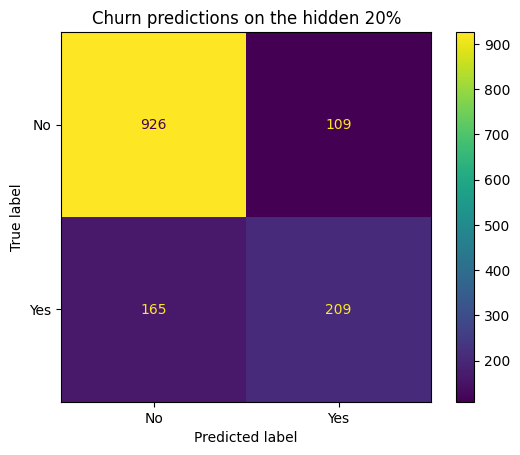

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Churn predictions on the hidden 20%")
plt.show()

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
print(scores)
print("mean", scores.mean())
print("spread", scores.std())

[0.83052351 0.80212955 0.80567879 0.79148181 0.79129663]
mean 0.8042220579636595
spread 0.014336303437951814


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

y_reg = df["MonthlyCharges"]
X_reg = df.drop(columns=["MonthlyCharges", "Churn", "customerID"])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         Xr_train.select_dtypes(include="object").columns),
        ("num", StandardScaler(),
         Xr_train.select_dtypes(exclude="object").columns)
    ])),
    ("model", LinearRegression())
])

reg_pipe.fit(Xr_train, yr_train)
reg_pred = reg_pipe.predict(Xr_test)
rmse = mean_squared_error(yr_test, reg_pred) ** 0.5

print("RMSE", round(rmse, 2))
print("typical bill", round(yr_test.mean(), 2))


RMSE 1.05
typical bill 64.35


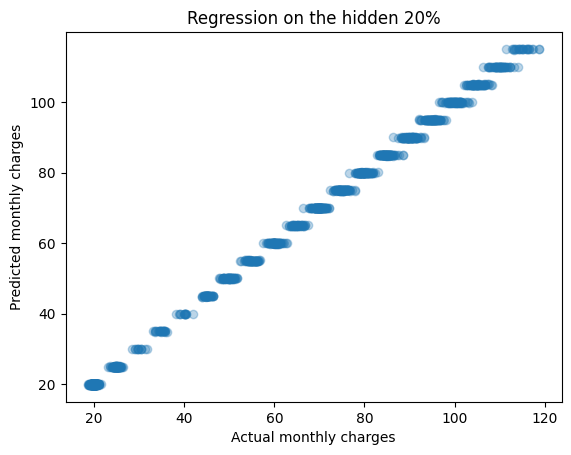

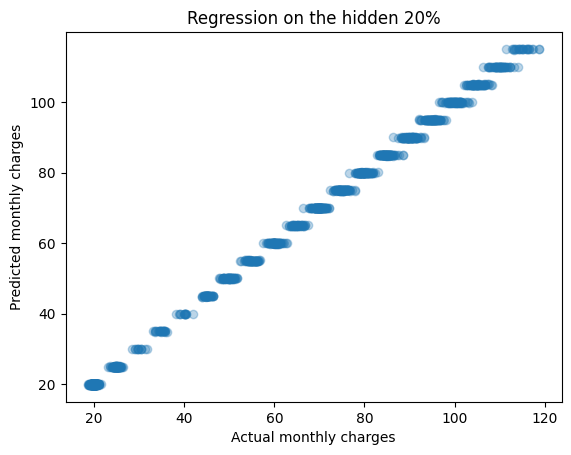

In [14]:
plt.scatter(yr_test, reg_pred, alpha=0.3)
plt.xlabel("Actual monthly charges")
plt.ylabel("Predicted monthly charges")
plt.title("Regression on the hidden 20%")
plt.show()

Sprint 2 results
-target for classification: Churn
-split: 80/20, stratified, random_state=42
-model: logistic regression, after one-hot encoding and scaling
-test accuracy about 0.806, 5-fold mean about 0.804
-Yes precision about 0.66, Yes recall about 0.56, Yes F1 about 0.60
-regression RMSE about 1.05, with the TotalCharges caveat